<a href="https://colab.research.google.com/github/iqlore-collab/API-PROJECTS/blob/main/API_weather_flights_advanced_operations_project_EN_DASHBOARD_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather + Flight Operations: my advanced API analytics project ✈️🌦️

In this notebook I wanted to go one step further than just “call an API and save a table”.

I combined two real-world data sources:

- **OpenWeather API** for weather forecasts,
- **AeroDataBox API** for airport flight operations.

The idea is simple but useful:

> Can I connect weather conditions with airport operations and build a small dashboard-ready dataset?

So here I collect weather, arrivals, departures, delays, cancellations, and then create airport-day summaries with a simple operational risk score.

This is still a prototype, but it feels much closer to a real data engineering / analytics project.

## 1. What I am building here

In this notebook I do the full workflow:

1. set up cities, airports, dates, and output folders,
2. download weather forecasts,
3. create weather risk features,
4. download arrivals and departures,
5. extract delay and cancellation signals,
6. combine weather + flights into one table,
7. build dashboard-ready summaries,
8. export clean CSV files.

The final goal is a dataset that could be used later in a dashboard or even as input for a delay-risk model.

In [1]:
import json
import time
from datetime import datetime, timedelta
from getpass import getpass
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt


## 2. Setup

I start with the basic Python libraries.

Nothing fancy here: just `requests`, `pandas`, `matplotlib`, and a few helpers for dates, paths, and secure API key input.

In [2]:
OPENWEATHER_API_KEY = getpass("Paste your OpenWeather API key: ")
RAPIDAPI_KEY = getpass("Paste your RapidAPI key for AeroDataBox: ")


Paste your OpenWeather API key: ··········
Paste your RapidAPI key for AeroDataBox: ··········


## 3. Configuration

This is the control panel of the notebook.

Here I decide:
- which airports I want to analyze,
- which cities they belong to,
- what date I want to check,
- what time windows I want to query,
- where the output files should go.

I added more airports than in the first version, so the project feels more like a real European airport operations snapshot.

In [3]:
OUTPUT_DIR = Path("outputs_weather_flights_advanced")
OUTPUT_DIR.mkdir(exist_ok=True)

REQUEST_SLEEP_SECONDS = 0.8
MAX_RETRIES = 3
TIMEOUT_SECONDS = 30

TARGET_DATE = (datetime.utcnow() + timedelta(days=1)).date()

CITY_AIRPORT_MAP = [
    {
        "city": "Berlin",
        "country_code": "DE",
        "lat": 52.5200,
        "lon": 13.4050,
        "airport_icao": "EDDB",
        "airport_name": "Berlin Brandenburg",
    },
    {
        "city": "Cologne",
        "country_code": "DE",
        "lat": 50.9375,
        "lon": 6.9603,
        "airport_icao": "EDDK",
        "airport_name": "Cologne Bonn",
    },
    {
        "city": "London",
        "country_code": "GB",
        "lat": 51.5074,
        "lon": -0.1278,
        "airport_icao": "EGLL",
        "airport_name": "London Heathrow",
    },
    {
        "city": "Paris",
        "country_code": "FR",
        "lat": 48.8566,
        "lon": 2.3522,
        "airport_icao": "LFPG",
        "airport_name": "Paris Charles de Gaulle",
    },
    {
        "city": "Amsterdam",
        "country_code": "NL",
        "lat": 52.3676,
        "lon": 4.9041,
        "airport_icao": "EHAM",
        "airport_name": "Amsterdam Schiphol",
    },
    {
        "city": "Madrid",
        "country_code": "ES",
        "lat": 40.4168,
        "lon": -3.7038,
        "airport_icao": "LEMD",
        "airport_name": "Adolfo Suárez Madrid–Barajas",
    },
]

TIME_WINDOWS = [
    (f"{TARGET_DATE}T00:00", f"{TARGET_DATE}T05:59"),
    (f"{TARGET_DATE}T06:00", f"{TARGET_DATE}T11:59"),
    (f"{TARGET_DATE}T12:00", f"{TARGET_DATE}T17:59"),
    (f"{TARGET_DATE}T18:00", f"{TARGET_DATE}T23:59"),
]

DIRECTIONS = ["Arrival", "Departure"]

df_city_airports = pd.DataFrame(CITY_AIRPORT_MAP)

df_city_airports


/tmp/ipykernel_3050/103702607.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  TARGET_DATE = (datetime.utcnow() + timedelta(days=1)).date()


,city,country_code,lat,lon,airport_icao,airport_name
0,Berlin,DE,52.5200,13.4050,EDDB,Berlin Brandenburg
1,Cologne,DE,50.9375,6.9603,EDDK,Cologne Bonn
2,London,GB,51.5074,-0.1278,EGLL,London Heathrow
3,Paris,FR,48.8566,2.3522,LFPG,Paris Charles de Gaulle
4,Amsterdam,NL,52.3676,4.9041,EHAM,Amsterdam Schiphol
5,Madrid,ES,40.4168,-3.7038,LEMD,Adolfo Suárez Madrid–Barajas


## 4. Shared API helper with retry logic

APIs are not always stable. Sometimes they fail, timeout, or hit a temporary limit.

So instead of writing `requests.get()` everywhere, I use one helper function that:
- retries failed requests,
- handles HTTP errors,
- handles connection problems,
- returns `None` safely if something goes wrong.

This makes the notebook much cleaner and safer to run.

In [4]:
def safe_get_json(
    url: str,
    headers: dict | None = None,
    params: dict | None = None,
    timeout: int = TIMEOUT_SECONDS,
    max_retries: int = MAX_RETRIES,
    sleep_seconds: float = REQUEST_SLEEP_SECONDS,
):
    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers=headers, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()

        except requests.exceptions.HTTPError as error:
            status_code = getattr(error.response, "status_code", None)
            print(f"HTTP error on attempt {attempt}/{max_retries}: {error}")

            if status_code in [429, 500, 502, 503, 504] and attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            try:
                print("Response preview:", response.text[:500])
            except Exception:
                pass
            return None

        except requests.exceptions.RequestException as error:
            print(f"Request error on attempt {attempt}/{max_retries}: {error}")

            if attempt < max_retries:
                time.sleep(sleep_seconds * attempt)
                continue

            return None

        except ValueError:
            print("Could not parse JSON response.")
            return None

    return None


## 5. Collect weather forecast data

First I collect weather forecasts for each city connected to an airport.

For every location I keep things like:
- temperature,
- humidity,
- pressure,
- wind speed,
- cloudiness,
- main weather condition.

This gives me the weather context around each airport.

In [5]:
OPENWEATHER_FORECAST_URL = "https://api.openweathermap.org/data/2.5/forecast"

def get_weather_forecast(lat: float, lon: float) -> dict | None:
    params = {
        "lat": lat,
        "lon": lon,
        "appid": OPENWEATHER_API_KEY,
        "units": "metric",
        "lang": "en",
    }

    return safe_get_json(OPENWEATHER_FORECAST_URL, params=params)


weather_rows = []
weather_log = []

for _, row in df_city_airports.iterrows():
    print(f"Downloading weather for {row['city']}...")

    forecast = get_weather_forecast(row["lat"], row["lon"])
    success = forecast is not None and "list" in forecast

    if success:
        for item in forecast["list"]:
            weather_rows.append({
                "city": row["city"],
                "airport_icao": row["airport_icao"],
                "datetime": item.get("dt_txt"),
                "temp": item["main"].get("temp"),
                "feels_like": item["main"].get("feels_like"),
                "humidity": item["main"].get("humidity"),
                "pressure": item["main"].get("pressure"),
                "wind_speed": item["wind"].get("speed"),
                "wind_deg": item["wind"].get("deg"),
                "cloudiness": item["clouds"].get("all"),
                "weather_main": item["weather"][0].get("main"),
                "description": item["weather"][0].get("description"),
            })

    weather_log.append({
        "city": row["city"],
        "airport_icao": row["airport_icao"],
        "success": success,
        "rows_returned": len(forecast.get("list", [])) if success else 0,
    })

    time.sleep(REQUEST_SLEEP_SECONDS)

df_weather = pd.DataFrame(weather_rows)
df_weather_log = pd.DataFrame(weather_log)

if not df_weather.empty:
    df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
    df_weather["date"] = df_weather["datetime"].dt.date
    df_weather["hour"] = df_weather["datetime"].dt.hour

display(df_weather_log)
display(df_weather.head())


,city,airport_icao,success,rows_returned
0,Berlin,EDDB,True,40
1,Cologne,EDDK,True,40
2,London,EGLL,True,40
3,Paris,LFPG,True,40
4,Amsterdam,EHAM,True,40
5,Madrid,LEMD,True,40


,city,airport_icao,datetime,temp,feels_like,humidity,pressure,wind_speed,wind_deg,cloudiness,weather_main,description,date,hour
0,Berlin,EDDB,2026-05-19 15:00:00,20.41,19.73,47,1018,2.47,292,33,Clouds,scattered clouds,2026-05-19,15
1,Berlin,EDDB,2026-05-19 18:00:00,19.60,18.90,49,1017,1.20,234,53,Clouds,broken clouds,2026-05-19,18
2,Berlin,EDDB,2026-05-19 21:00:00,14.98,14.15,62,1019,1.58,245,70,Clouds,broken clouds,2026-05-19,21
3,Berlin,EDDB,2026-05-20 00:00:00,9.12,9.12,67,1019,1.24,199,72,Clouds,broken clouds,2026-05-20,0
4,Berlin,EDDB,2026-05-20 03:00:00,12.35,11.57,74,1019,1.77,183,93,Clouds,overcast clouds,2026-05-20,3


## 6. Create weather risk features

Raw weather numbers are useful, but I also wanted something easier to interpret.

So I create a simple **weather risk level**:

- `low`
- `medium`
- `high`

This is based on wind speed, cloudiness, humidity, and weather type.

It is not a scientific aviation risk model, but it is a good first analytics feature for a portfolio project.

In [6]:
def classify_weather_risk(row: pd.Series) -> str:
    score = 0

    if row.get("max_wind_speed", 0) >= 12:
        score += 2
    elif row.get("max_wind_speed", 0) >= 8:
        score += 1

    if row.get("avg_cloudiness", 0) >= 80:
        score += 1

    if row.get("avg_humidity", 0) >= 85:
        score += 1

    weather = str(row.get("dominant_weather", "")).lower()
    if weather in ["rain", "snow", "thunderstorm"]:
        score += 2
    elif weather in ["drizzle", "mist", "fog"]:
        score += 1

    if score >= 4:
        return "high"
    if score >= 2:
        return "medium"
    return "low"


if not df_weather.empty:
    df_weather_daily = (
        df_weather
        .groupby(["city", "airport_icao", "date"], as_index=False)
        .agg(
            avg_temp=("temp", "mean"),
            min_temp=("temp", "min"),
            max_temp=("temp", "max"),
            avg_humidity=("humidity", "mean"),
            avg_pressure=("pressure", "mean"),
            avg_wind_speed=("wind_speed", "mean"),
            max_wind_speed=("wind_speed", "max"),
            avg_cloudiness=("cloudiness", "mean"),
            dominant_weather=("weather_main", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        )
        .round(2)
    )

    df_weather_daily["weather_risk_level"] = df_weather_daily.apply(classify_weather_risk, axis=1)
else:
    df_weather_daily = pd.DataFrame()

df_weather_daily.head()


,city,airport_icao,date,avg_temp,min_temp,max_temp,avg_humidity,avg_pressure,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather,weather_risk_level
0,Amsterdam,EHAM,2026-05-19,14.16,13.28,15.73,84.67,1014.00,5.03,5.18,80.00,Rain,medium
1,Amsterdam,EHAM,2026-05-20,14.09,11.38,17.02,79.00,1017.88,5.24,7.01,69.75,Clouds,low
2,Amsterdam,EHAM,2026-05-21,15.77,11.97,20.10,72.50,1026.25,3.63,4.97,71.00,Clouds,low
3,Amsterdam,EHAM,2026-05-22,18.59,12.17,24.66,64.38,1028.00,1.65,1.96,48.25,Clouds,low
4,Amsterdam,EHAM,2026-05-23,19.57,14.71,25.50,71.75,1025.88,2.72,3.98,64.00,Clouds,low


## 7. Collect arrivals and departures

Now I collect flight operations from AeroDataBox.

In the first version I focused mainly on arrivals.  
Here I also add **departures**, because airport operations are not only about incoming flights.

For each airport and time window I download:
- arrivals,
- departures,
- airline,
- aircraft,
- origin airport,
- destination airport,
- scheduled and revised times.

This gives me a much richer operations dataset.

In [7]:
AERODATABOX_BASE_URL = "https://aerodatabox.p.rapidapi.com"
AERODATABOX_HEADERS = {
    "X-RapidAPI-Key": RAPIDAPI_KEY,
    "X-RapidAPI-Host": "aerodatabox.p.rapidapi.com",
}


def get_airport_flights(
    airport_icao: str,
    start_time: str,
    end_time: str,
    direction: str,
):
    url = f"{AERODATABOX_BASE_URL}/flights/airports/icao/{airport_icao}/{start_time}/{end_time}"
    params = {
        "direction": direction,
        "withCancelled": "true",
        "withCodeshared": "true",
        "withCargo": "false",
        "withPrivate": "false",
    }

    return safe_get_json(url, headers=AERODATABOX_HEADERS, params=params)


def get_nested(data: dict, *keys):
    value = data
    for key in keys:
        if not isinstance(value, dict):
            return None
        value = value.get(key)
    return value


def get_time_value(section: dict, kind: str = "scheduled") -> str | None:
    """Extract local time from different AeroDataBox response shapes.

    AeroDataBox responses may expose timestamps either as:
    - scheduledTime / revisedTime dictionaries with a "local" field
    - scheduledTimeLocal / revisedTimeLocal direct string fields
    - scheduledTimeUtc / revisedTimeUtc direct string fields

    This helper makes the notebook robust across API response variants.
    """
    if not isinstance(section, dict):
        return None

    nested_key = f"{kind}Time"
    direct_local_key = f"{kind}TimeLocal"
    direct_utc_key = f"{kind}TimeUtc"

    return (
        get_nested(section, nested_key, "local")
        or section.get(direct_local_key)
        or get_nested(section, nested_key, "utc")
        or section.get(direct_utc_key)
    )


def flatten_flights_response(response, airport_icao: str, city: str, direction: str) -> list[dict]:
    if not response:
        return []

    key = "arrivals" if direction == "Arrival" else "departures"
    flights = response.get(key, [])

    rows = []

    for flight in flights:
        departure = flight.get("departure", {}) or {}
        arrival = flight.get("arrival", {}) or {}
        airline = flight.get("airline", {}) or {}
        aircraft = flight.get("aircraft", {}) or {}

        rows.append({
            "city": city,
            "airport_icao": airport_icao,
            "direction": direction,
            "flight_number": flight.get("number"),
            "status": flight.get("status"),
            "airline_name": airline.get("name"),
            "airline_iata": airline.get("iata"),
            "airline_icao": airline.get("icao"),
            "aircraft_model": aircraft.get("model"),
            "aircraft_reg": aircraft.get("reg"),

            "departure_airport_name": get_nested(departure, "airport", "name"),
            "departure_airport_icao": get_nested(departure, "airport", "icao"),
            "departure_airport_iata": get_nested(departure, "airport", "iata"),

            "arrival_airport_name": get_nested(arrival, "airport", "name"),
            "arrival_airport_icao": get_nested(arrival, "airport", "icao"),
            "arrival_airport_iata": get_nested(arrival, "airport", "iata"),

            "scheduled_departure_local": get_time_value(departure, "scheduled"),
            "revised_departure_local": get_time_value(departure, "revised"),
            "scheduled_arrival_local": get_time_value(arrival, "scheduled"),
            "revised_arrival_local": get_time_value(arrival, "revised"),
        })

    return rows


In [8]:
flight_rows = []
flight_log = []

for _, airport in df_city_airports.iterrows():
    for direction in DIRECTIONS:
        for start_time, end_time in TIME_WINDOWS:
            print(f"Fetching {direction.lower()}s for {airport['airport_icao']}: {start_time} -> {end_time}")

            response = get_airport_flights(
                airport_icao=airport["airport_icao"],
                start_time=start_time,
                end_time=end_time,
                direction=direction,
            )

            rows = flatten_flights_response(
                response=response,
                airport_icao=airport["airport_icao"],
                city=airport["city"],
                direction=direction,
            )

            # Keep the API query window as fallback metadata.
            # Some AeroDataBox responses do not expose scheduled/revised timestamps
            # in the shape expected by the parser, but the query window still tells us
            # which airport/date/time block these flights came from.
            for row in rows:
                row["query_start_time"] = start_time
                row["query_end_time"] = end_time
                row["query_date"] = str(TARGET_DATE)

            flight_rows.extend(rows)

            flight_log.append({
                "city": airport["city"],
                "airport_icao": airport["airport_icao"],
                "direction": direction,
                "start_time": start_time,
                "end_time": end_time,
                "success": response is not None,
                "rows_returned": len(rows),
            })

            time.sleep(REQUEST_SLEEP_SECONDS)

df_flights = pd.DataFrame(flight_rows)
df_flight_log = pd.DataFrame(flight_log)

print("Flight rows:", len(df_flights))
display(df_flight_log.head())
display(df_flights.head())


Fetching arrivals for EDDB: 2026-05-20T00:00 -> 2026-05-20T05:59
Request error on attempt 1/3: Expecting value: line 1 column 1 (char 0)
Request error on attempt 2/3: Expecting value: line 1 column 1 (char 0)
Request error on attempt 3/3: Expecting value: line 1 column 1 (char 0)
Fetching arrivals for EDDB: 2026-05-20T06:00 -> 2026-05-20T11:59
Fetching arrivals for EDDB: 2026-05-20T12:00 -> 2026-05-20T17:59
Fetching arrivals for EDDB: 2026-05-20T18:00 -> 2026-05-20T23:59
Fetching departures for EDDB: 2026-05-20T00:00 -> 2026-05-20T05:59
Fetching departures for EDDB: 2026-05-20T06:00 -> 2026-05-20T11:59
Fetching departures for EDDB: 2026-05-20T12:00 -> 2026-05-20T17:59
Fetching departures for EDDB: 2026-05-20T18:00 -> 2026-05-20T23:59
Fetching arrivals for EDDK: 2026-05-20T00:00 -> 2026-05-20T05:59
Fetching arrivals for EDDK: 2026-05-20T06:00 -> 2026-05-20T11:59
Fetching arrivals for EDDK: 2026-05-20T12:00 -> 2026-05-20T17:59
Fetching arrivals for EDDK: 2026-05-20T18:00 -> 2026-05-20T23

,city,airport_icao,direction,start_time,end_time,success,rows_returned
0,Berlin,EDDB,Arrival,2026-05-20T00:00,2026-05-20T05:59,False,0
1,Berlin,EDDB,Arrival,2026-05-20T06:00,2026-05-20T11:59,True,139
2,Berlin,EDDB,Arrival,2026-05-20T12:00,2026-05-20T17:59,True,158
3,Berlin,EDDB,Arrival,2026-05-20T18:00,2026-05-20T23:59,True,155
4,Berlin,EDDB,Departure,2026-05-20T00:00,2026-05-20T05:59,True,3


,city,airport_icao,direction,flight_number,status,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,...,arrival_airport_name,arrival_airport_icao,arrival_airport_iata,scheduled_departure_local,revised_departure_local,scheduled_arrival_local,revised_arrival_local,query_start_time,query_end_time,query_date
0,Berlin,EDDB,Arrival,SR 127,Expected,SundAir,SR,SDR,Airbus A320,None,...,None,None,None,None,None,None,None,2026-05-20T06:00,2026-05-20T11:59,2026-05-20
1,Berlin,EDDB,Arrival,XQ 1768,Expected,Sun Express,XQ,SXS,Boeing 737 MAX 8,None,...,None,None,None,None,None,None,None,2026-05-20T06:00,2026-05-20T11:59,2026-05-20
2,Berlin,EDDB,Arrival,HU 489,Expected,Hainan,HU,CHH,Boeing 787-9,None,...,None,None,None,None,None,None,None,2026-05-20T06:00,2026-05-20T11:59,2026-05-20
3,Berlin,EDDB,Arrival,W4 3109,Expected,Aero Services Executive,W4,WMT,Airbus A321-200,None,...,None,None,None,None,None,None,None,2026-05-20T06:00,2026-05-20T11:59,2026-05-20
4,Berlin,EDDB,Arrival,UA 962,Expected,United,UA,UAL,Boeing 767-300 (winglets),None,...,None,None,None,None,None,None,None,2026-05-20T06:00,2026-05-20T11:59,2026-05-20


## 8. Clean timestamps and derive delay features

The API sometimes returns flight rows without scheduled/revised timestamps in the expected response shape.

To keep the dashboard useful, I use a fallback:

- if exact scheduled/revised flight time is available, I use it;
- otherwise I use the API query window start time.

This means flight counts and airport-day summaries can still be built, even when exact delay calculations are unavailable.

Delay metrics should be interpreted carefully when many rows use the query-window fallback.


In [9]:
datetime_cols = [
    "scheduled_departure_local",
    "revised_departure_local",
    "scheduled_arrival_local",
    "revised_arrival_local",
    "query_start_time",
    "query_end_time",
]

for col in datetime_cols:
    if col in df_flights.columns:
        df_flights[col] = pd.to_datetime(df_flights[col], errors="coerce")


def first_available_time(row: pd.Series, columns: list[str]):
    for col in columns:
        value = row.get(col)
        if pd.notna(value):
            return value
    return pd.NaT


def compute_delay_minutes(row: pd.Series) -> float | None:
    if row["direction"] == "Arrival":
        scheduled = row.get("scheduled_arrival_local")
        revised = row.get("revised_arrival_local")
    else:
        scheduled = row.get("scheduled_departure_local")
        revised = row.get("revised_departure_local")

    if pd.isna(scheduled) or pd.isna(revised):
        return None

    return (revised - scheduled).total_seconds() / 60


if not df_flights.empty:
    df_flights["operation_time_local"] = df_flights.apply(
        lambda row: first_available_time(
            row,
            [
                "scheduled_arrival_local" if row["direction"] == "Arrival" else "scheduled_departure_local",
                "revised_arrival_local" if row["direction"] == "Arrival" else "revised_departure_local",
                # Fallback: use API query window if exact scheduled/revised time is unavailable.
                "query_start_time",
            ],
        ),
        axis=1,
    )

    df_flights["operation_date"] = df_flights["operation_time_local"].dt.date
    df_flights["operation_hour"] = df_flights["operation_time_local"].dt.hour
    df_flights["delay_minutes"] = df_flights.apply(compute_delay_minutes, axis=1)
    df_flights["is_delayed_15min"] = df_flights["delay_minutes"].fillna(0).astype(float) >= 15
    df_flights["is_cancelled"] = df_flights["status"].astype(str).str.lower().str.contains("cancel", na=False)

    df_flights["time_source"] = df_flights.apply(
        lambda row: "flight_timestamp"
        if (
            pd.notna(row.get("scheduled_arrival_local"))
            or pd.notna(row.get("scheduled_departure_local"))
            or pd.notna(row.get("revised_arrival_local"))
            or pd.notna(row.get("revised_departure_local"))
        )
        else "query_window_fallback",
        axis=1,
    )

print("Rows with valid operation time:", df_flights["operation_time_local"].notna().sum() if not df_flights.empty else 0)
print("Rows without valid operation time:", df_flights["operation_time_local"].isna().sum() if not df_flights.empty else 0)

if not df_flights.empty and "time_source" in df_flights.columns:
    display(df_flights["time_source"].value_counts(dropna=False).rename_axis("time_source").reset_index(name="rows"))

df_flights.head()


/tmp/ipykernel_3050/3617147670.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_flights["is_delayed_15min"] = df_flights["delay_minutes"].fillna(0).astype(float) >= 15


Rows with valid operation time: 20193
Rows without valid operation time: 0


,time_source,rows
0,query_window_fallback,20193


,city,airport_icao,direction,flight_number,status,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,...,query_start_time,query_end_time,query_date,operation_time_local,operation_date,operation_hour,delay_minutes,is_delayed_15min,is_cancelled,time_source
0,Berlin,EDDB,Arrival,SR 127,Expected,SundAir,SR,SDR,Airbus A320,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
1,Berlin,EDDB,Arrival,XQ 1768,Expected,Sun Express,XQ,SXS,Boeing 737 MAX 8,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
2,Berlin,EDDB,Arrival,HU 489,Expected,Hainan,HU,CHH,Boeing 787-9,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
3,Berlin,EDDB,Arrival,W4 3109,Expected,Aero Services Executive,W4,WMT,Airbus A321-200,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
4,Berlin,EDDB,Arrival,UA 962,Expected,United,UA,UAL,Boeing 767-300 (winglets),None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback


## 9. Build operational summaries

Now I turn raw flight rows into something more useful.

For each airport and day I calculate:
- total number of flights,
- arrivals,
- departures,
- number of airlines,
- number of connected airports,
- average delay,
- number of delayed flights,
- cancellation count.

This is the kind of table I would actually use in a dashboard.

In [10]:
if not df_flights.empty and "operation_date" in df_flights.columns:
    df_flights_valid_time = df_flights.dropna(subset=["operation_date"]).copy()
else:
    df_flights_valid_time = pd.DataFrame()

if not df_flights_valid_time.empty:
    df_operations_daily = (
        df_flights_valid_time
        .groupby(["city", "airport_icao", "operation_date"], as_index=False)
        .agg(
            total_flights=("flight_number", "count"),
            arrivals=("direction", lambda x: (x == "Arrival").sum()),
            departures=("direction", lambda x: (x == "Departure").sum()),
            unique_airlines=("airline_name", "nunique"),
            unique_airports_connected=(
                "departure_airport_icao",
                lambda x: x.nunique(dropna=True),
            ),
            avg_delay_minutes=("delay_minutes", "mean"),
            delayed_15min_flights=("is_delayed_15min", "sum"),
            cancelled_flights=("is_cancelled", "sum"),
        )
        .rename(columns={"operation_date": "date"})
    )

    df_operations_daily["delay_rate_15min"] = (
        df_operations_daily["delayed_15min_flights"] / df_operations_daily["total_flights"]
    ).round(3)

    df_operations_daily["avg_delay_minutes"] = df_operations_daily["avg_delay_minutes"].round(2)
else:
    df_operations_daily = pd.DataFrame(
        columns=[
            "city",
            "airport_icao",
            "date",
            "total_flights",
            "arrivals",
            "departures",
            "unique_airlines",
            "unique_airports_connected",
            "avg_delay_minutes",
            "delayed_15min_flights",
            "cancelled_flights",
            "delay_rate_15min",
        ]
    )

print("Rows in daily operations summary:", len(df_operations_daily))
df_operations_daily.head()


Rows in daily operations summary: 6


,city,airport_icao,date,total_flights,arrivals,departures,unique_airlines,unique_airports_connected,avg_delay_minutes,delayed_15min_flights,cancelled_flights,delay_rate_15min
0,Amsterdam,EHAM,2026-05-20,4938,2467,2471,89,0,NaN,0,12,0.0
1,Berlin,EDDB,2026-05-20,895,452,443,82,0,NaN,0,0,0.0
2,Cologne,EDDK,2026-05-20,192,95,97,17,0,NaN,0,0,0.0
3,London,EGLL,2026-05-20,5129,2538,2591,92,0,NaN,0,3,0.0
4,Madrid,LEMD,2026-05-20,4086,2113,1973,94,0,NaN,0,0,0.0


## 10. Combine weather and operations

This is the key step of the whole notebook.

I join:

- daily weather summary,
- daily airport operations summary,

using:

- city,
- airport ICAO,
- date.

Now I have one table where I can compare traffic and weather side by side.

In [11]:
if not df_weather_daily.empty and not df_operations_daily.empty:
    df_weather_daily["date"] = pd.to_datetime(df_weather_daily["date"], errors="coerce").dt.date
    df_operations_daily["date"] = pd.to_datetime(df_operations_daily["date"], errors="coerce").dt.date

    df_weather_operations = pd.merge(
        df_operations_daily,
        df_weather_daily,
        on=["city", "airport_icao", "date"],
        how="left",
    )
else:
    df_weather_operations = pd.DataFrame()

print("Weather daily rows:", len(df_weather_daily))
print("Operations daily rows:", len(df_operations_daily))
print("Combined rows:", len(df_weather_operations))

df_weather_operations.head()


Weather daily rows: 36
Operations daily rows: 6
Combined rows: 6


,city,airport_icao,date,total_flights,arrivals,departures,unique_airlines,unique_airports_connected,avg_delay_minutes,delayed_15min_flights,...,avg_temp,min_temp,max_temp,avg_humidity,avg_pressure,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather,weather_risk_level
0,Amsterdam,EHAM,2026-05-20,4938,2467,2471,89,0,NaN,0,...,14.09,11.38,17.02,79.00,1017.88,5.24,7.01,69.75,Clouds,low
1,Berlin,EDDB,2026-05-20,895,452,443,82,0,NaN,0,...,13.97,9.12,17.04,77.50,1020.50,2.69,4.52,90.00,Clouds,low
2,Cologne,EDDK,2026-05-20,192,95,97,17,0,NaN,0,...,14.20,11.67,17.11,87.00,1020.88,3.77,5.53,80.25,Rain,high
3,London,EGLL,2026-05-20,5129,2538,2591,92,0,NaN,0,...,14.99,12.09,20.07,71.75,1017.50,5.24,7.00,83.75,Clouds,low
4,Madrid,LEMD,2026-05-20,4086,2113,1973,94,0,NaN,0,...,22.55,16.71,28.74,39.75,1022.12,2.06,3.55,84.62,Clouds,low


## 11. Simple disruption risk score

I wanted one simple score that combines weather and operations.

So I create an **operation risk score** based on:

- weather risk,
- delay rate,
- cancellations.

This is not a production model.  
But it is a nice first step toward a more advanced delay or disruption analysis.

In [12]:
def operational_risk_score(row: pd.Series) -> int:
    score = 0

    weather_risk = row.get("weather_risk_level")
    if weather_risk == "high":
        score += 3
    elif weather_risk == "medium":
        score += 1

    if row.get("delay_rate_15min", 0) >= 0.3:
        score += 2
    elif row.get("delay_rate_15min", 0) >= 0.15:
        score += 1

    if row.get("cancelled_flights", 0) >= 3:
        score += 2
    elif row.get("cancelled_flights", 0) >= 1:
        score += 1

    return score


def risk_level(score: int) -> str:
    if score >= 5:
        return "high"
    if score >= 2:
        return "medium"
    return "low"


if not df_weather_operations.empty:
    df_weather_operations["operation_risk_score"] = df_weather_operations.apply(operational_risk_score, axis=1)
    df_weather_operations["operation_risk_level"] = df_weather_operations["operation_risk_score"].apply(risk_level)

    display(df_weather_operations.sort_values("operation_risk_score", ascending=False).head(10))
else:
    print("No combined weather + operations rows available.")
    print("Check whether flight rows have valid operation dates and whether dates match weather forecast dates.")


,city,airport_icao,date,total_flights,arrivals,departures,unique_airlines,unique_airports_connected,avg_delay_minutes,delayed_15min_flights,...,max_temp,avg_humidity,avg_pressure,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather,weather_risk_level,operation_risk_score,operation_risk_level
2,Cologne,EDDK,2026-05-20,192,95,97,17,0,NaN,0,...,17.11,87.00,1020.88,3.77,5.53,80.25,Rain,high,3,medium
0,Amsterdam,EHAM,2026-05-20,4938,2467,2471,89,0,NaN,0,...,17.02,79.00,1017.88,5.24,7.01,69.75,Clouds,low,2,medium
5,Paris,LFPG,2026-05-20,4953,2464,2489,106,0,NaN,0,...,19.91,71.50,1022.88,3.84,5.51,79.88,Clouds,low,2,medium
3,London,EGLL,2026-05-20,5129,2538,2591,92,0,NaN,0,...,20.07,71.75,1017.50,5.24,7.00,83.75,Clouds,low,2,medium
1,Berlin,EDDB,2026-05-20,895,452,443,82,0,NaN,0,...,17.04,77.50,1020.50,2.69,4.52,90.00,Clouds,low,0,low
4,Madrid,LEMD,2026-05-20,4086,2113,1973,94,0,NaN,0,...,28.74,39.75,1022.12,2.06,3.55,84.62,Clouds,low,0,low


## 12. Dashboard-ready views

Here I create a clean table that is ready for a dashboard.

I keep only the columns that would be useful for a first airport operations view:

- airport,
- date,
- arrivals and departures,
- delay rate,
- cancellations,
- temperature,
- wind,
- cloudiness,
- weather risk,
- operation risk.

This table is basically the “final product” of the notebook.

In [13]:
dashboard_columns = [
    "city",
    "airport_icao",
    "date",
    "total_flights",
    "arrivals",
    "departures",
    "unique_airlines",
    "avg_delay_minutes",
    "delay_rate_15min",
    "cancelled_flights",
    "avg_temp",
    "avg_wind_speed",
    "max_wind_speed",
    "avg_cloudiness",
    "dominant_weather",
    "weather_risk_level",
    "operation_risk_score",
    "operation_risk_level",
]

if not df_weather_operations.empty:
    available_dashboard_columns = [col for col in dashboard_columns if col in df_weather_operations.columns]
    dashboard_airport_daily = df_weather_operations[available_dashboard_columns].copy()
else:
    dashboard_airport_daily = pd.DataFrame(columns=dashboard_columns)

dashboard_airport_daily


,city,airport_icao,date,total_flights,arrivals,departures,unique_airlines,avg_delay_minutes,delay_rate_15min,cancelled_flights,avg_temp,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather,weather_risk_level,operation_risk_score,operation_risk_level
0,Amsterdam,EHAM,2026-05-20,4938,2467,2471,89,NaN,0.0,12,14.09,5.24,7.01,69.75,Clouds,low,2,medium
1,Berlin,EDDB,2026-05-20,895,452,443,82,NaN,0.0,0,13.97,2.69,4.52,90.00,Clouds,low,0,low
2,Cologne,EDDK,2026-05-20,192,95,97,17,NaN,0.0,0,14.20,3.77,5.53,80.25,Rain,high,3,medium
3,London,EGLL,2026-05-20,5129,2538,2591,92,NaN,0.0,3,14.99,5.24,7.00,83.75,Clouds,low,2,medium
4,Madrid,LEMD,2026-05-20,4086,2113,1973,94,NaN,0.0,0,22.55,2.06,3.55,84.62,Clouds,low,0,low
5,Paris,LFPG,2026-05-20,4953,2464,2489,106,NaN,0.0,4,16.45,3.84,5.51,79.88,Clouds,low,2,medium


## 13. Visual analysis

Now I add a few simple charts.

The goal is not to make a full dashboard inside the notebook, but to quickly see whether the data makes sense:

- total flights by airport,
- delay rate vs wind speed,
- risk score by airport.

These charts help turn the API data into something readable.

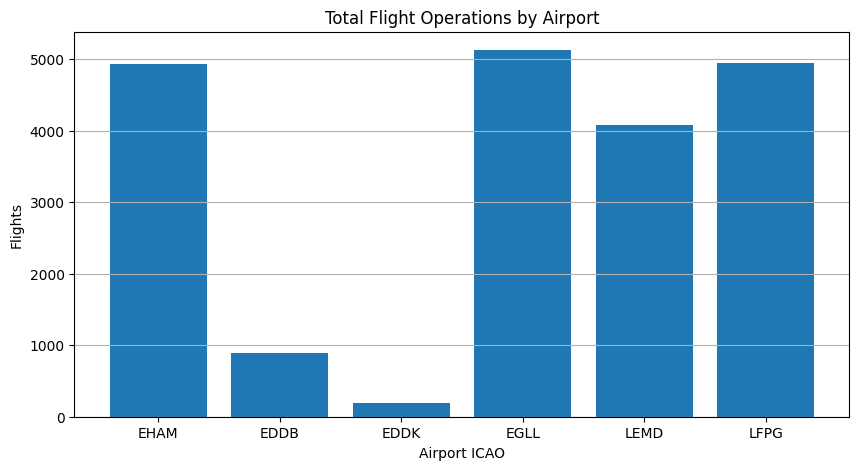

In [14]:
if not dashboard_airport_daily.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(dashboard_airport_daily["airport_icao"], dashboard_airport_daily["total_flights"])
    plt.title("Total Flight Operations by Airport")
    plt.xlabel("Airport ICAO")
    plt.ylabel("Flights")
    plt.grid(axis="y")
    plt.show()
else:
    print("No dashboard data to plot.")


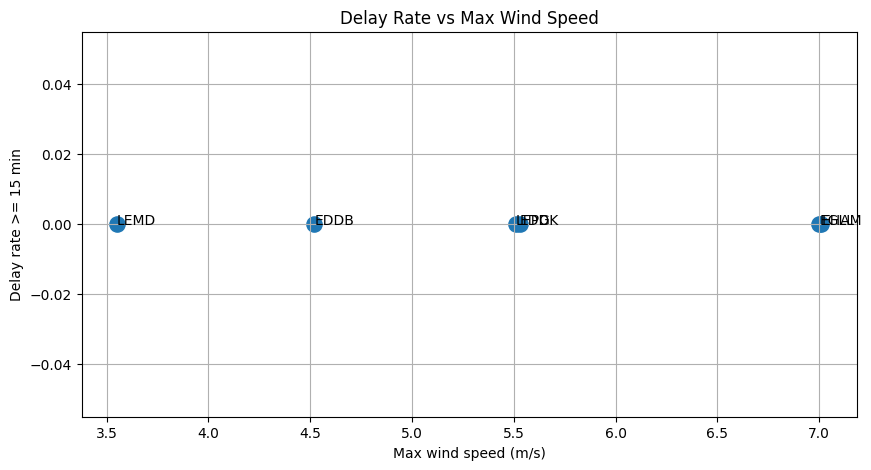

In [15]:
if not dashboard_airport_daily.empty:
    plt.figure(figsize=(10, 5))
    plt.scatter(
        dashboard_airport_daily["max_wind_speed"],
        dashboard_airport_daily["delay_rate_15min"],
        s=120,
    )

    for _, row in dashboard_airport_daily.iterrows():
        plt.text(row["max_wind_speed"], row["delay_rate_15min"], row["airport_icao"])

    plt.title("Delay Rate vs Max Wind Speed")
    plt.xlabel("Max wind speed (m/s)")
    plt.ylabel("Delay rate >= 15 min")
    plt.grid(True)
    plt.show()
else:
    print("No dashboard data to plot.")


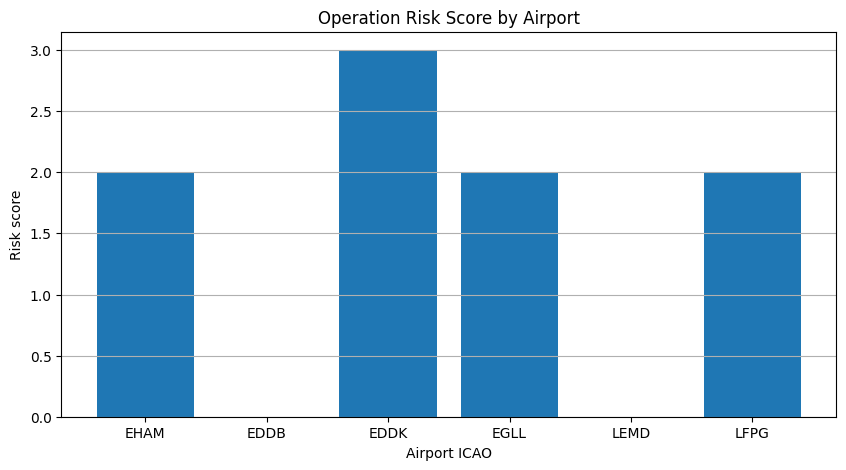

In [16]:
if not dashboard_airport_daily.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(
        dashboard_airport_daily["airport_icao"],
        dashboard_airport_daily["operation_risk_score"],
    )
    plt.title("Operation Risk Score by Airport")
    plt.xlabel("Airport ICAO")
    plt.ylabel("Risk score")
    plt.grid(axis="y")
    plt.show()
else:
    print("No dashboard data to plot.")


## 14. Database-ready tables

I also prepare the data in a more database-friendly way.

The idea is to separate the output into tables like:

- airport dimension,
- weather fact table,
- flight operations fact table,
- airport daily operations mart.

This is how I would start thinking about the project if I wanted to move it toward a real ETL/data warehouse workflow.

These tables are not pushed into a database here, but they are shaped in a way that would make that step much easier later.

In [17]:
dim_airports = df_city_airports.copy()

fact_weather_forecast = df_weather.copy()
fact_flight_operations = df_flights.copy()
mart_airport_daily_operations = dashboard_airport_daily.copy()

display(dim_airports.head())
display(fact_weather_forecast.head())
display(fact_flight_operations.head())
display(mart_airport_daily_operations.head())


,city,country_code,lat,lon,airport_icao,airport_name
0,Berlin,DE,52.5200,13.4050,EDDB,Berlin Brandenburg
1,Cologne,DE,50.9375,6.9603,EDDK,Cologne Bonn
2,London,GB,51.5074,-0.1278,EGLL,London Heathrow
3,Paris,FR,48.8566,2.3522,LFPG,Paris Charles de Gaulle
4,Amsterdam,NL,52.3676,4.9041,EHAM,Amsterdam Schiphol


,city,airport_icao,datetime,temp,feels_like,humidity,pressure,wind_speed,wind_deg,cloudiness,weather_main,description,date,hour
0,Berlin,EDDB,2026-05-19 15:00:00,20.41,19.73,47,1018,2.47,292,33,Clouds,scattered clouds,2026-05-19,15
1,Berlin,EDDB,2026-05-19 18:00:00,19.60,18.90,49,1017,1.20,234,53,Clouds,broken clouds,2026-05-19,18
2,Berlin,EDDB,2026-05-19 21:00:00,14.98,14.15,62,1019,1.58,245,70,Clouds,broken clouds,2026-05-19,21
3,Berlin,EDDB,2026-05-20 00:00:00,9.12,9.12,67,1019,1.24,199,72,Clouds,broken clouds,2026-05-20,0
4,Berlin,EDDB,2026-05-20 03:00:00,12.35,11.57,74,1019,1.77,183,93,Clouds,overcast clouds,2026-05-20,3


,city,airport_icao,direction,flight_number,status,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,...,query_start_time,query_end_time,query_date,operation_time_local,operation_date,operation_hour,delay_minutes,is_delayed_15min,is_cancelled,time_source
0,Berlin,EDDB,Arrival,SR 127,Expected,SundAir,SR,SDR,Airbus A320,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
1,Berlin,EDDB,Arrival,XQ 1768,Expected,Sun Express,XQ,SXS,Boeing 737 MAX 8,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
2,Berlin,EDDB,Arrival,HU 489,Expected,Hainan,HU,CHH,Boeing 787-9,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
3,Berlin,EDDB,Arrival,W4 3109,Expected,Aero Services Executive,W4,WMT,Airbus A321-200,None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback
4,Berlin,EDDB,Arrival,UA 962,Expected,United,UA,UAL,Boeing 767-300 (winglets),None,...,2026-05-20 06:00:00,2026-05-20 11:59:00,2026-05-20,2026-05-20 06:00:00,2026-05-20,6,None,False,False,query_window_fallback


,city,airport_icao,date,total_flights,arrivals,departures,unique_airlines,avg_delay_minutes,delay_rate_15min,cancelled_flights,avg_temp,avg_wind_speed,max_wind_speed,avg_cloudiness,dominant_weather,weather_risk_level,operation_risk_score,operation_risk_level
0,Amsterdam,EHAM,2026-05-20,4938,2467,2471,89,NaN,0.0,12,14.09,5.24,7.01,69.75,Clouds,low,2,medium
1,Berlin,EDDB,2026-05-20,895,452,443,82,NaN,0.0,0,13.97,2.69,4.52,90.00,Clouds,low,0,low
2,Cologne,EDDK,2026-05-20,192,95,97,17,NaN,0.0,0,14.20,3.77,5.53,80.25,Rain,high,3,medium
3,London,EGLL,2026-05-20,5129,2538,2591,92,NaN,0.0,3,14.99,5.24,7.00,83.75,Clouds,low,2,medium
4,Madrid,LEMD,2026-05-20,4086,2113,1973,94,NaN,0.0,0,22.55,2.06,3.55,84.62,Clouds,low,0,low


## 15. Export all outputs

At the end I save everything to CSV.

This makes the notebook GitHub-friendly and easy to reuse.

I also export a `metadata.json` file, so each run has information about:
- when it was created,
- which airports were used,
- what date was queried,
- how many rows were collected,
- which files were created.

In [18]:
weather_path = OUTPUT_DIR / "fact_weather_forecast.csv"
weather_daily_path = OUTPUT_DIR / "weather_daily_summary.csv"
flights_path = OUTPUT_DIR / "fact_flight_operations.csv"
operations_daily_path = OUTPUT_DIR / "flight_operations_daily.csv"
combined_path = OUTPUT_DIR / "weather_operations_combined_daily.csv"
dashboard_path = OUTPUT_DIR / "dashboard_airport_daily.csv"
dim_airports_path = OUTPUT_DIR / "dim_airports.csv"
weather_log_path = OUTPUT_DIR / "weather_api_log.csv"
flight_log_path = OUTPUT_DIR / "flight_api_log.csv"
metadata_path = OUTPUT_DIR / "metadata.json"

fact_weather_forecast.to_csv(weather_path, index=False)
df_weather_daily.to_csv(weather_daily_path, index=False)
fact_flight_operations.to_csv(flights_path, index=False)
df_operations_daily.to_csv(operations_daily_path, index=False)
df_weather_operations.to_csv(combined_path, index=False)
dashboard_airport_daily.to_csv(dashboard_path, index=False)
dim_airports.to_csv(dim_airports_path, index=False)
df_weather_log.to_csv(weather_log_path, index=False)
df_flight_log.to_csv(flight_log_path, index=False)

metadata = {
    "run_timestamp_utc": datetime.utcnow().isoformat(),
    "target_date": str(TARGET_DATE),
    "city_airport_map": CITY_AIRPORT_MAP,
    "time_windows": TIME_WINDOWS,
    "directions": DIRECTIONS,
    "rows": {
        "weather_forecast": int(len(fact_weather_forecast)),
        "flight_operations": int(len(fact_flight_operations)),
        "airport_daily_dashboard": int(len(dashboard_airport_daily)),
        "weather_api_calls": int(len(df_weather_log)),
        "flight_api_calls": int(len(df_flight_log)),
    },
    "output_files": [
        str(weather_path),
        str(weather_daily_path),
        str(flights_path),
        str(operations_daily_path),
        str(combined_path),
        str(dashboard_path),
        str(dim_airports_path),
        str(weather_log_path),
        str(flight_log_path),
    ],
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved files:")
for path in [
    weather_path,
    weather_daily_path,
    flights_path,
    operations_daily_path,
    combined_path,
    dashboard_path,
    dim_airports_path,
    weather_log_path,
    flight_log_path,
    metadata_path,
]:
    print(path)


Saved files:
outputs_weather_flights_advanced/fact_weather_forecast.csv
outputs_weather_flights_advanced/weather_daily_summary.csv
outputs_weather_flights_advanced/fact_flight_operations.csv
outputs_weather_flights_advanced/flight_operations_daily.csv
outputs_weather_flights_advanced/weather_operations_combined_daily.csv
outputs_weather_flights_advanced/dashboard_airport_daily.csv
outputs_weather_flights_advanced/dim_airports.csv
outputs_weather_flights_advanced/weather_api_log.csv
outputs_weather_flights_advanced/flight_api_log.csv
outputs_weather_flights_advanced/metadata.json


/tmp/ipykernel_3050/1639792926.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_timestamp_utc": datetime.utcnow().isoformat(),


## 16. How I would schedule this workflow

If I wanted to turn this into a real recurring pipeline, I would not run it manually in Colab.

The next step would be to move the logic into Python scripts and schedule it with:

- GitHub Actions,
- cron,
- Airflow,
- Prefect,
- Dagster,
- or a cloud function.

The daily output could then be appended to a database and connected to a dashboard.

This is the part where the notebook becomes a blueprint for a real data pipeline, not just a one-time analysis.

## 17. Final notes

This version feels much more complete than a simple API notebook.

I now have:

- multiple countries and airports,
- weather forecasts,
- arrivals and departures,
- delay-related features,
- cancellation flags,
- weather risk levels,
- operation risk scores,
- dashboard-ready output,
- database-style tables,
- metadata for reproducibility.

It is still a prototype, but it shows the full idea:  
**collect real API data, clean it, combine it, analyze it, and prepare it for reporting.**

One thing I like about this version is that it does not stop at “I downloaded some data”.

It turns the data into something structured:
- facts,
- dimensions,
- daily summaries,
- dashboard tables,
- risk labels,
- exported outputs.

That makes the notebook feel more like a real end-to-end analytics project.